### Prerequsite - Upgrade Scikit Learn
The current workspace has scikit-learn v0.19.1 installed. However, you can upgrade scikit-learn to 0.24.x. and use this [OneHotEncoder](https://scikit-learn.org/0.21/modules/generated/sklearn.preprocessing.OneHotEncoder.html) library. 


In [1]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 0.19.1.


In [2]:
import os
os.environ['PATH'] = f"{os.environ['PATH']}:/root/.local/bin"

In [15]:
!python -m pip install --upgrade scikit-learn
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

    100% |████████████████████████████████| 20.0MB 1.9MB/s eta 0:00:01
    100% |████████████████████████████████| 13.4MB 3.8MB/s eta 0:00:01
tensorflow 1.3.0 requires tensorflow-tensorboard<0.2.0,>=0.1.0, which is not installed.
  Found existing installation: numpy 1.12.1
    Uninstalling numpy-1.12.1:
      Successfully uninstalled numpy-1.12.1
  Found existing installation: scikit-learn 0.19.1
    Uninstalling scikit-learn-0.19.1:
      Successfully uninstalled scikit-learn-0.19.1
The scikit-learn version is 0.19.1.


In [1]:
# Now you can import and use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
# your code goes here

In [ ]:
# Similarly, should you need any other package, they can install it as:
!python -m pip install 'tensorflow-tensorboard<0.2.0,>=0.1.0'

# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [1]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# magic word for producing visualizations in notebook
%matplotlib inline

'''
Import note: The classroom currently uses sklearn version 0.19.
If you need to use an imputer, it is available in sklearn.preprocessing.Imputer,
instead of sklearn.impute as in newer versions of sklearn.
'''
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [2]:
# Load in the general demographics data.
data1 = pd.read_csv("Udacity_AZDIAS_Subset.csv", sep=';')
data2 = pd.read_csv("Udacity_CUSTOMERS_Subset.csv", sep=';')
# Load in the feature summary file.
summary = pd.read_csv("AZDIAS_Feature_Summary.csv", sep=';')

In [3]:
# Check the structure of the data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).
data1.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [4]:
data2.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,2,0,4.0,1,1,20.0,5.0,2.0,2.0,10.0,5.0,1,4,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,3,0.0,0.0,1,3,10.0,2.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,1.0,5.0,1992.0,W,7.0,1,1A,13,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0
1,-1,4,1,NaN,5,1,5,1,3,2,2,0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,3,6,2,6,7,5,3,4,1,3,3,2,4,1,3,0.0,0.0,1,3,11.0,3.0,0.0,NaN,NaN,0.0,9.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1,4,2,2.0,5,1,5,1,4,4,2,0,3.0,1,2,13.0,3.0,1.0,1.0,10.0,5.0,1,4,5.0,2,2,1,3,3,7,7,1,2,7,5,6,4,1,1,0.0,0.0,2,3,6.0,1.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,8.0,1.0,1992.0,W,2.0,5,5D,34,2.0,2.0,0.0,0.0,0.0,3.0,7.0,4.0,1.0,3.0,3.0,3.0,1.0,7.0,433.0,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0
3,1,4,1,2.0,5,1,5,2,1,2,6,0,10.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,1,3.0,6,5,3,4,7,5,3,4,3,3,3,3,3,4,0,0.0,0.0,1,1,8.0,0.0,0.0,4.0,NaN,NaN,9.0,0.0,NaN,2.0,2.0,1992.0,W,7.0,4,4C,24,3.0,0.0,0.0,0.0,1.0,4.0,7.0,1.0,7.0,4.0,3.0,4.0,2.0,6.0,755.0,3.0,2.0,1.0,0.0,1.0,3.0,4.0,1.0,3.0,1.0
4,-1,3,1,6.0,3,1,4,4,5,2,2,1960,2.0,0,3,31.0,10.0,10.0,5.0,1.0,1.0,1,8,5.0,4,5,4,6,5,6,4,5,5,3,5,2,5,4,1,0.0,0.0,2,1,20.0,4.0,0.0,6.0,2.0,2.0,9.0,7.0,0.0,3.0,1.0,1992.0,W,3.0,7,7B,41,0.0,3.0,2.0,0.0,0.0,3.0,3.0,4.0,4.0,3.0,4.0,3.0,5.0,7.0,513.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,3.0,5.0,1.0


In [5]:
summary.head()

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


In [6]:
data1.count()

AGER_TYP                 891221
ALTERSKATEGORIE_GROB     891221
ANREDE_KZ                891221
CJT_GESAMTTYP            886367
FINANZ_MINIMALIST        891221
FINANZ_SPARER            891221
FINANZ_VORSORGER         891221
FINANZ_ANLEGER           891221
FINANZ_UNAUFFAELLIGER    891221
FINANZ_HAUSBAUER         891221
FINANZTYP                891221
GEBURTSJAHR              891221
GFK_URLAUBERTYP          886367
GREEN_AVANTGARDE         891221
HEALTH_TYP               891221
LP_LEBENSPHASE_FEIN      886367
LP_LEBENSPHASE_GROB      886367
LP_FAMILIE_FEIN          886367
LP_FAMILIE_GROB          886367
LP_STATUS_FEIN           886367
LP_STATUS_GROB           886367
NATIONALITAET_KZ         891221
PRAEGENDE_JUGENDJAHRE    891221
RETOURTYP_BK_S           886367
SEMIO_SOZ                891221
SEMIO_FAM                891221
SEMIO_REL                891221
SEMIO_MAT                891221
SEMIO_VERT               891221
SEMIO_LUST               891221
SEMIO_ERL                891221
SEMIO_KU

In [7]:
data2.count()

AGER_TYP                 191652
ALTERSKATEGORIE_GROB     191652
ANREDE_KZ                191652
CJT_GESAMTTYP            188439
FINANZ_MINIMALIST        191652
FINANZ_SPARER            191652
FINANZ_VORSORGER         191652
FINANZ_ANLEGER           191652
FINANZ_UNAUFFAELLIGER    191652
FINANZ_HAUSBAUER         191652
FINANZTYP                191652
GEBURTSJAHR              191652
GFK_URLAUBERTYP          188439
GREEN_AVANTGARDE         191652
HEALTH_TYP               191652
LP_LEBENSPHASE_FEIN      188439
LP_LEBENSPHASE_GROB      188439
LP_FAMILIE_FEIN          188439
LP_FAMILIE_GROB          188439
LP_STATUS_FEIN           188439
LP_STATUS_GROB           188439
NATIONALITAET_KZ         191652
PRAEGENDE_JUGENDJAHRE    191652
RETOURTYP_BK_S           188439
SEMIO_SOZ                191652
SEMIO_FAM                191652
SEMIO_REL                191652
SEMIO_MAT                191652
SEMIO_VERT               191652
SEMIO_LUST               191652
SEMIO_ERL                191652
SEMIO_KU

In [8]:
summary.count()

attribute             85
information_level     85
type                  85
missing_or_unknown    85
dtype: int64

> **Tip**: Add additional cells to keep everything in reasonably-sized chunks! Keyboard shortcut `esc --> a` (press escape to enter command mode, then press the 'A' key) adds a new cell before the active cell, and `esc --> b` adds a new cell after the active cell. If you need to convert an active cell to a markdown cell, use `esc --> m` and to convert to a code cell, use `esc --> y`. 

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

After reviewing the dictionary, we can see there are a lot of missing records in our two datasets! As an example, here is a look at how often `-1` (which is a universal unknown) appears in our first dataset:

In [9]:
(data1 == -1).sum().sum()

1011091

Over a million records, wow! Now, we can go ahead and convert all of the 'unknown' or 'missing' data to NaN values.

In [10]:
def string_to_list(x):
    new_list = []
    x = x[1:-1].split(',')

    for i in x:
        i = i.strip()
        try:
            new_list.append(int(i))
        except ValueError:
            new_list.append(i)

    return new_list

summary['NA_tags'] = summary['missing_or_unknown'].apply(string_to_list)
att_index = summary.set_index('attribute')

for column in data1.columns:
    na_values = att_index.loc[column, 'NA_tags']
    data1[column].replace(na_values, np.nan, inplace=True)

In [11]:
data1.isnull().sum().sum()

8373929

#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [12]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.

# Let's check out the first dataset.
missing_counts = data1.isna().sum()
print(missing_counts)

AGER_TYP                 685843
ALTERSKATEGORIE_GROB       2881
ANREDE_KZ                     0
CJT_GESAMTTYP              4854
FINANZ_MINIMALIST             0
FINANZ_SPARER                 0
FINANZ_VORSORGER              0
FINANZ_ANLEGER                0
FINANZ_UNAUFFAELLIGER         0
FINANZ_HAUSBAUER              0
FINANZTYP                     0
GEBURTSJAHR              392318
GFK_URLAUBERTYP            4854
GREEN_AVANTGARDE              0
HEALTH_TYP               111196
LP_LEBENSPHASE_FEIN       97632
LP_LEBENSPHASE_GROB       94572
LP_FAMILIE_FEIN           77792
LP_FAMILIE_GROB           77792
LP_STATUS_FEIN             4854
LP_STATUS_GROB             4854
NATIONALITAET_KZ         108315
PRAEGENDE_JUGENDJAHRE    108164
RETOURTYP_BK_S             4854
SEMIO_SOZ                     0
SEMIO_FAM                     0
SEMIO_REL                     0
SEMIO_MAT                     0
SEMIO_VERT                    0
SEMIO_LUST                    0
SEMIO_ERL                     0
SEMIO_KU

In [13]:
# Quite a lot of missing values! Next, let's see the second dataset...
missing_counts2 = data2.isna().sum()
print(missing_counts2)

AGER_TYP                      0
ALTERSKATEGORIE_GROB          0
ANREDE_KZ                     0
CJT_GESAMTTYP              3213
FINANZ_MINIMALIST             0
FINANZ_SPARER                 0
FINANZ_VORSORGER              0
FINANZ_ANLEGER                0
FINANZ_UNAUFFAELLIGER         0
FINANZ_HAUSBAUER              0
FINANZTYP                     0
GEBURTSJAHR                   0
GFK_URLAUBERTYP            3213
GREEN_AVANTGARDE              0
HEALTH_TYP                    0
LP_LEBENSPHASE_FEIN        3213
LP_LEBENSPHASE_GROB        3213
LP_FAMILIE_FEIN            3213
LP_FAMILIE_GROB            3213
LP_STATUS_FEIN             3213
LP_STATUS_GROB             3213
NATIONALITAET_KZ              0
PRAEGENDE_JUGENDJAHRE         0
RETOURTYP_BK_S             3213
SEMIO_SOZ                     0
SEMIO_FAM                     0
SEMIO_REL                     0
SEMIO_MAT                     0
SEMIO_VERT                    0
SEMIO_LUST                    0
SEMIO_ERL                     0
SEMIO_KU

Let's now take a look at the percentage of missing data by column.

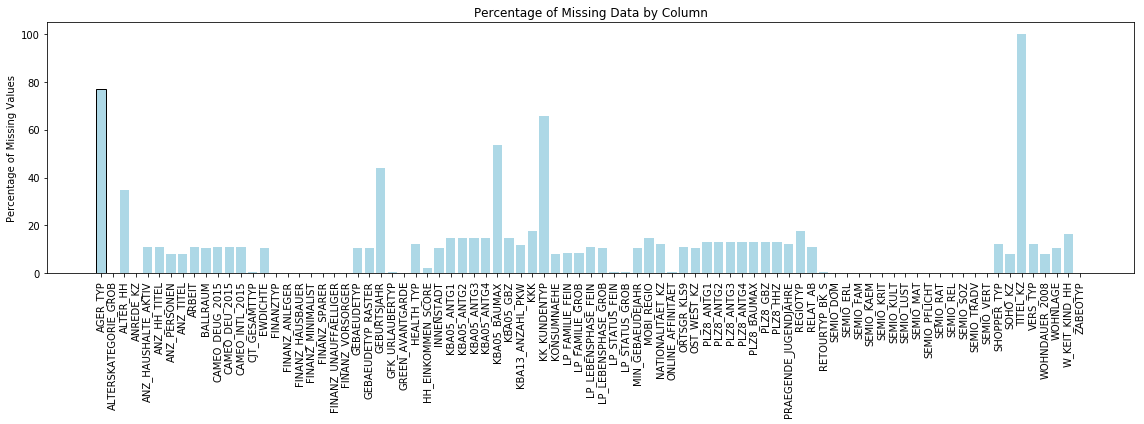

In [14]:
# Investigate patterns in the amount of missing data in each column.
missing_percent = data1.isna().mean() * 100

plt.figure(figsize=(16,6))
plt.bar(missing_percent.index, missing_percent.values, color='lightblue', edgecolor='k')
plt.xticks(rotation=90, ha='center')

plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Data by Column')
plt.tight_layout()
plt.show()

We can see that there are several columns with over 30% of the data missing, and one with almost 100%! Let's look at the second dataset now.

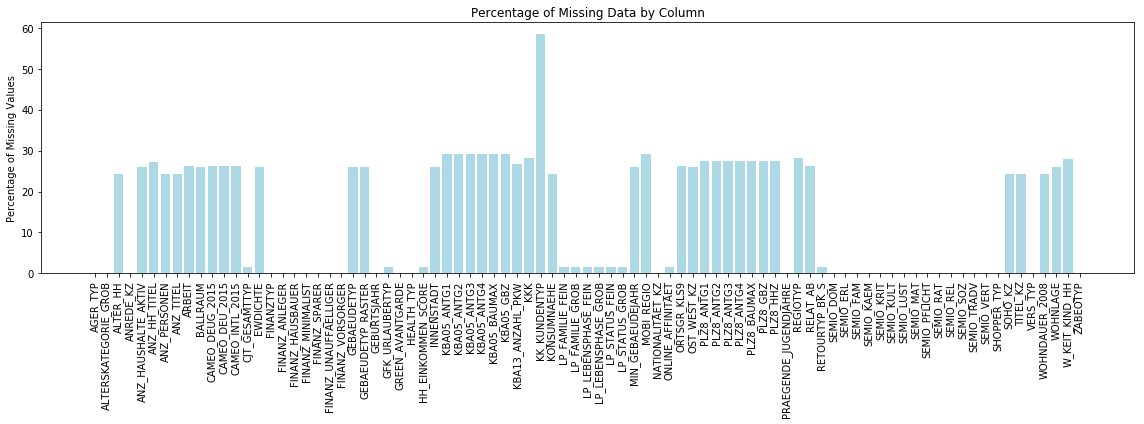

In [15]:
# Investigate patterns in the amount of missing data in each column.
missing_percent = data2.isna().mean() * 100

plt.figure(figsize=(16,6))
plt.bar(missing_percent.index, missing_percent.values, color='lightblue', edgecolor='k')
plt.xticks(rotation=90, ha='center')

plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Data by Column')
plt.tight_layout()
plt.show()

The pattern is almost exactly the same, except now we see almost all of the columns which were previously around 10% of missing data now at 30%!

Overall, we see 6 columns which are obvious outliers in the dataset: `ALTER_HH`, `GEBURTSJAHR`, `KBA05_BAUMAX`, `AGER_TYP`, `TITEL_KZ` and `KK_KUNDENTYP`. We will remove these next, as they have too much missing data to be very useful to our analysis.

In [16]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)

outlier_cols = [
    'TITEL_KZ',
    'AGER_TYP',
    'ALTER_HH',
    'GEBURTSJAHR',
    'KBA05_BAUMAX',
    'KK_KUNDENTYP'
]

# Drop from both datasets
data1 = data1.drop(columns=outlier_cols)
data2 = data2.drop(columns=outlier_cols)

#### Discussion 1.1.2: Assess Missing Data in Each Column

We do see that a large number of columns have about 10% missing data in the first dataset, but this number goes up to 30% in the second dataset, and the amount of missing data is roughly equal between these columns. We did remove a few outliers which were significantly above 30% missing data, `ALTER_HH`, `GEBURTSJAHR`, `KBA05_BAUMAX`, `AGER_TYP`, `TITEL_KZ`, and `KK_KUNDENTYP`.

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

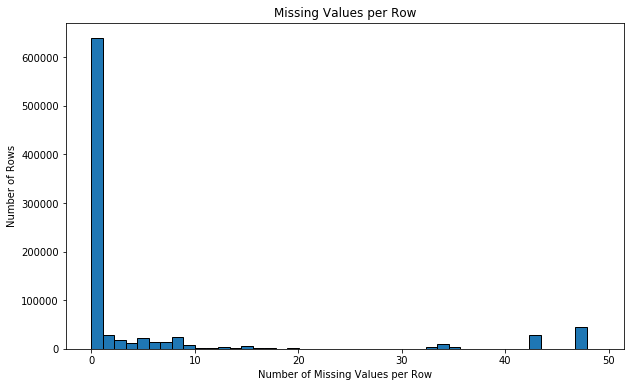

In [17]:
# How much data is missing in each row of the dataset?
row_missing_counts = data1.isna().sum(axis=1)

plt.figure(figsize=(10,6))
plt.hist(row_missing_counts, bins=44, edgecolor='k')
plt.xlabel('Number of Missing Values per Row')
plt.ylabel('Number of Rows')
plt.title('Missing Values per Row')
plt.show()


Based on this, it looks like the majority of our rows have 1 missing data point, but we can see there are also almost a hundred thousand records with 39 missing values in our first dataset! Let's investigate further by dividing the data into two subsets. Our threshold for removing data will be 20 missing values.

In [18]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.
threshold = 20

data_low_missing_1 = data1[row_missing_counts <= threshold]
data_high_missing_1 = data1[row_missing_counts > threshold]

data_low_missing_2 = data2[row_missing_counts <= threshold]
data_high_missing_2 = data2[row_missing_counts > threshold]

print(data_low_missing_1.shape)
print(data_high_missing_1.shape)
print(data_low_missing_2.shape)
print(data_high_missing_2.shape)

(797426, 79)
(93795, 79)
(171388, 79)
(20264, 79)


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if __name__ == '__main__':


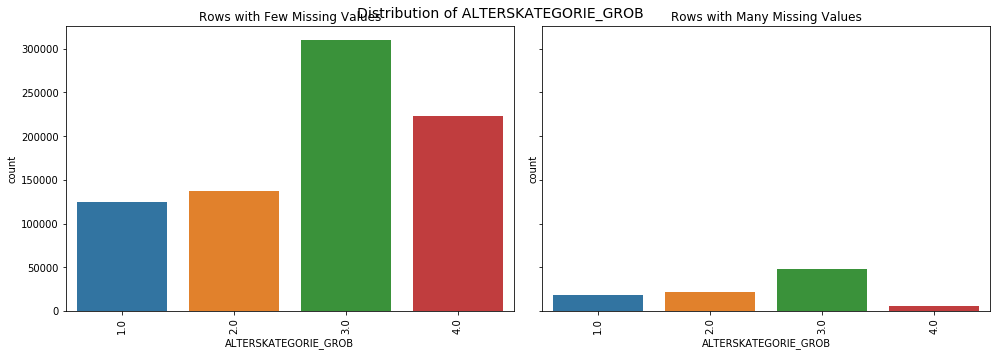

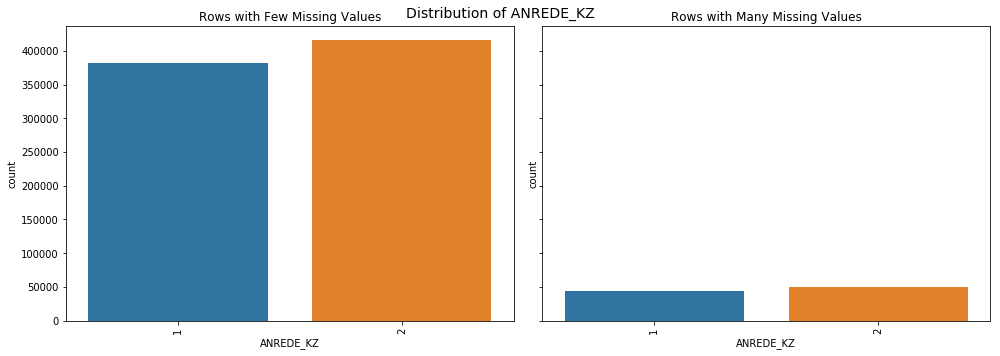

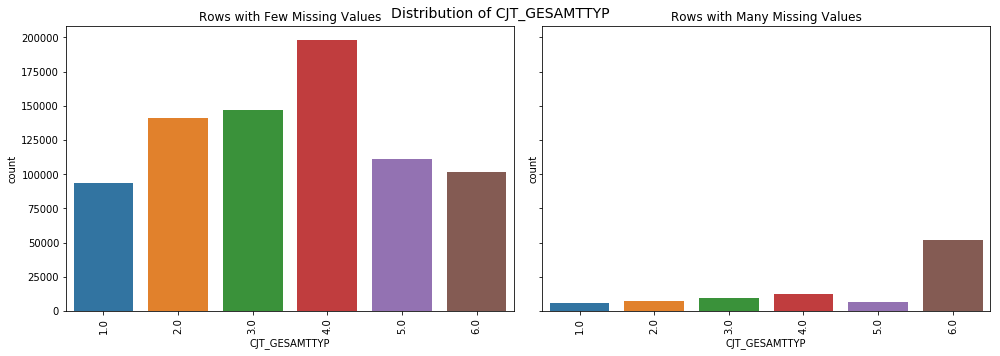

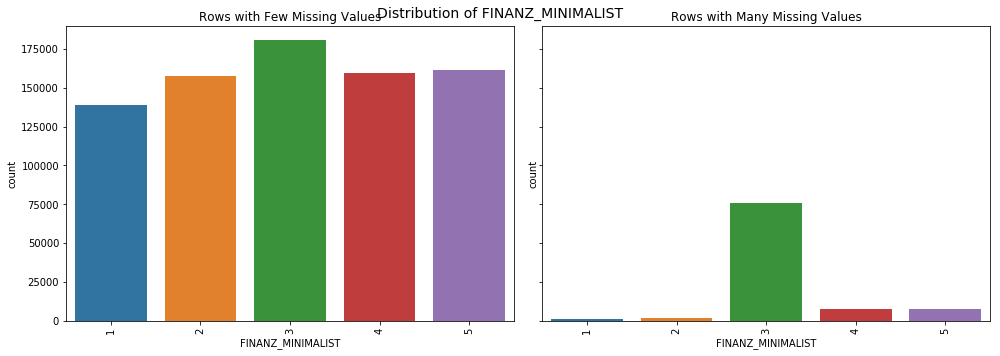

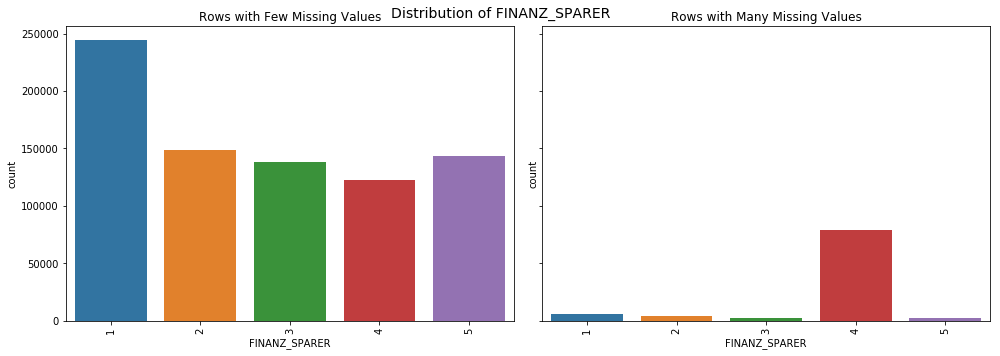

In [19]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.
low_missing_cols_1 = data1.isna().mean()
low_missing_cols_1 = low_missing_cols_1[low_missing_cols_1 < 0.05].index.tolist()

# Select at least five columns
compare_cols = low_missing_cols_1[:5]
# We have manually confirmed that the top 5 columns are the same in both datasets, so we can continue using the first dataset

for col in compare_cols:

    fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

    sns.countplot(x=col, data=data_low_missing_1, ax=axes[0])
    axes[0].set_title('Rows with Few Missing Values')
    axes[0].tick_params(axis='x', rotation=90)

    sns.countplot(x=col, data=data_high_missing_1, ax=axes[1])
    axes[1].set_title('Rows with Many Missing Values')
    axes[1].tick_params(axis='x', rotation=90)

    fig.suptitle(f'Distribution of {col}', fontsize=14)
    plt.tight_layout()
    plt.show()


In [20]:
# Overwrite the original dataframe
data1 = data_low_missing_1.copy()
data2 = data_low_missing_2.copy()

#### Discussion 1.1.3: Assess Missing Data in Each Row

This can appear complicated, so let's break it down. Charts on the left side show the rows in the dataset (with their values plotted on the x-axis) with a small number of missing values, while on the right side, we see rows that have many missing values. We can see that the rows with small amounts of missing values are relatively consistent (other than an outlier in the `AGER_TYP` column), but rows with many missing values are not normally distributed and appear highly localized to specific regions. For now, we will exclude all rows with high (>=20) numbers of missing values and continue.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [21]:
# How many features are there of each data type?
summary.type.value_counts()

ordinal        49
categorical    21
numeric         7
mixed           7
interval        1
Name: type, dtype: int64

#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [22]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?
categorical_cols = summary.loc[
    summary['type'] == 'categorical', 'attribute'
].values
categorical_cols = [c for c in categorical_cols if c in data1.columns]

data1[categorical_cols].nunique().sort_values()

ANREDE_KZ            2
OST_WEST_KZ          2
VERS_TYP             2
SOHO_KZ              2
GREEN_AVANTGARDE     2
NATIONALITAET_KZ     3
SHOPPER_TYP          4
LP_STATUS_GROB       5
LP_FAMILIE_GROB      5
FINANZTYP            6
ZABEOTYP             6
CJT_GESAMTTYP        6
GEBAEUDETYP          7
CAMEO_DEUG_2015      9
LP_STATUS_FEIN      10
LP_FAMILIE_FEIN     11
GFK_URLAUBERTYP     12
CAMEO_DEU_2015      44
dtype: int64

In [23]:
data1[categorical_cols].dtypes

ANREDE_KZ             int64
CJT_GESAMTTYP       float64
FINANZTYP             int64
GFK_URLAUBERTYP     float64
GREEN_AVANTGARDE      int64
LP_FAMILIE_FEIN     float64
LP_FAMILIE_GROB     float64
LP_STATUS_FEIN      float64
LP_STATUS_GROB      float64
NATIONALITAET_KZ    float64
SHOPPER_TYP         float64
SOHO_KZ             float64
VERS_TYP            float64
ZABEOTYP              int64
GEBAEUDETYP         float64
OST_WEST_KZ          object
CAMEO_DEUG_2015      object
CAMEO_DEU_2015       object
dtype: object

We will drop `CAMEO_DEUG_2015` and `CAMEO_DEU_2015` as they both have too many object variables, but we'll just re-encode `OST_WEST_KZ`.

In [24]:
# Remove object columns with too many possible values
cameo_cols = [
    'CAMEO_DEUG_2015',
    'CAMEO_DEU_2015',
]

data1 = data1.drop(columns=cameo_cols)
data2 = data2.drop(columns=cameo_cols)

In [25]:
# Re-encode categorical variable(s) to be kept in the analysis.
data1['OST_WEST_KZ'] = data1['OST_WEST_KZ'].astype('category').cat.codes
data2['OST_WEST_KZ'] = data2['OST_WEST_KZ'].astype('category').cat.codes

In [26]:
# Double checking our conversion was successful
categorical_cols = [c for c in categorical_cols if c in data1.columns]
data1[categorical_cols].dtypes

ANREDE_KZ             int64
CJT_GESAMTTYP       float64
FINANZTYP             int64
GFK_URLAUBERTYP     float64
GREEN_AVANTGARDE      int64
LP_FAMILIE_FEIN     float64
LP_FAMILIE_GROB     float64
LP_STATUS_FEIN      float64
LP_STATUS_GROB      float64
NATIONALITAET_KZ    float64
SHOPPER_TYP         float64
SOHO_KZ             float64
VERS_TYP            float64
ZABEOTYP              int64
GEBAEUDETYP         float64
OST_WEST_KZ            int8
dtype: object

#### Discussion 1.2.1: Re-Encode Categorical Features

In our categorical data, we found that most of the columns contained numeric data, luckily, but two of the columns had object-only data (`CAMEO_DEUG_2015` and `CAMEO_DEU_2015`) with a large number of variables, so we went ahead and dropped those. Our only other column with object data was `OST_WEST_KZ`, but it only had 2 possible values, so we converted this to numeric data.

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [27]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.

def map_decade(val):
    if val in [1, 2]:
        return 1940
    elif val in [3, 4]:
        return 1950
    elif val in [5, 6, 7]:
        return 1960
    elif val in [8, 9]:
        return 1970
    elif val in [10, 11, 12, 13]:
        return 1980
    elif val in [14, 15]:
        return 1990
    else:
        return np.nan
    
data1['PRAEGENDE_JUGENDJAHRE_DECADE'] = data1['PRAEGENDE_JUGENDJAHRE'].apply(map_decade)
data2['PRAEGENDE_JUGENDJAHRE_DECADE'] = data2['PRAEGENDE_JUGENDJAHRE'].apply(map_decade)

def map_movement(val):
    if val in [2, 4, 6, 7, 9, 11, 13, 15]:
        return 1
    elif val in [1, 3, 5, 8, 10, 12, 14]:
        return 0
    else:
        return np.nan

data1['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = data1['PRAEGENDE_JUGENDJAHRE'].apply(map_movement)
data2['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = data2['PRAEGENDE_JUGENDJAHRE'].apply(map_movement)

In [28]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.

data1['CAMEO_INTL_2015'] = pd.to_numeric(data1['CAMEO_INTL_2015'], errors='coerce')
data2['CAMEO_INTL_2015'] = pd.to_numeric(data2['CAMEO_INTL_2015'], errors='coerce')
data1['CAMEO_WEALTH'] = data1['CAMEO_INTL_2015'] // 10
data1['CAMEO_LIFESTAGE'] = data1['CAMEO_INTL_2015'] % 10

data2['CAMEO_WEALTH'] = data2['CAMEO_INTL_2015'] // 10
data2['CAMEO_LIFESTAGE'] = data2['CAMEO_INTL_2015'] % 10

In [29]:
# Finally, we will delete our old columns, as the data is no longer needed.
data1.drop(columns=['PRAEGENDE_JUGENDJAHRE'], inplace=True)
data2.drop(columns=['PRAEGENDE_JUGENDJAHRE'], inplace=True)
data1.drop(columns=['CAMEO_INTL_2015'], inplace=True)
data2.drop(columns=['CAMEO_INTL_2015'], inplace=True)

In [30]:
# Let's check whether that was successful. We will see the new values at the end of this head() display.
data1.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
1,1.0,2,5.0,1,5,2,5,4,5,1,10.0,0,3.0,21.0,6.0,5.0,3.0,2.0,1.0,1.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,1.0,2.0,5,2.0,0.0,6.0,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,1,4.0,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0,1990.0,0.0,5.0,1.0
2,3.0,2,3.0,1,4,1,2,3,5,1,10.0,1,3.0,3.0,1.0,1.0,1.0,3.0,2.0,1.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,0.0,1.0,5,1.0,0.0,4.0,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,1,2.0,1.0,3.0,1.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0,1990.0,1.0,2.0,4.0
3,4.0,2,2.0,4,2,5,2,1,2,6,1.0,0,2.0,NaN,NaN,NaN,NaN,9.0,4.0,1.0,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,0.0,1.0,3,0.0,0.0,1.0,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,1,7.0,4.0,1.0,0.0,0.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0,1970.0,0.0,1.0,2.0
4,3.0,1,5.0,4,3,4,1,3,2,5,5.0,0,3.0,32.0,10.0,10.0,5.0,3.0,2.0,1.0,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,0.0,2.0,4,4.0,0.0,5.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,1,3.0,1.0,4.0,1.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0,1970.0,0.0,4.0,3.0
5,1.0,2,2.0,3,1,5,2,2,5,2,1.0,0,3.0,8.0,2.0,1.0,1.0,4.0,2.0,1.0,3.0,2,4,7,4,2,2,2,5,7,4,4,4,7,6,0.0,0.0,2.0,4,1.0,0.0,5.0,6.0,9.0,5.0,0.0,1.0,5.0,1992.0,1,7.0,2.0,2.0,0.0,0.0,4.0,6.0,2.0,7.0,4.0,4.0,4.0,1.0,5.0,1300.0,2.0,3.0,1.0,1.0,1.0,5.0,5.0,2.0,3.0,3.0,1950.0,0.0,5.0,4.0


#### Discussion 1.2.2: Engineer Mixed-Type Features

For `PRAEGENDE_JUGENDJAHRE`, we derived two new variables - the decade, and the associated movement (0 or 1), and for `CAMEO_INTL_2015`, we also derived two variables - wealth and lifestage. We have dropped the original columns and now have only the derived ones.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [31]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)

# Looking for other 'mixed' column types.
mixed_cols = summary.loc[summary['type'] == 'mixed', 'attribute'].values
mixed_cols_in_data = [c for c in mixed_cols if c in data1.columns]

In [32]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

# Let's drop all of the columns with the `mixed` datatype left.
data1 = data1.drop(columns=mixed_cols_in_data, errors='ignore')
data2 = data2.drop(columns=mixed_cols_in_data, errors='ignore')

In [33]:
# An updated view of our dataframe.
data1.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
1,1.0,2,5.0,1,5,2,5,4,5,1,10.0,0,3.0,5.0,3.0,2.0,1.0,1.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,1.0,2.0,5,2.0,0.0,6.0,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,1,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,5.0,4.0,3.0,5.0,4.0,1990.0,0.0,5.0,1.0
2,3.0,2,3.0,1,4,1,2,3,5,1,10.0,1,3.0,1.0,1.0,3.0,2.0,1.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,0.0,1.0,5,1.0,0.0,4.0,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,1,1.0,3.0,1.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,4.0,4.0,3.0,5.0,2.0,1990.0,1.0,2.0,4.0
3,4.0,2,2.0,4,2,5,2,1,2,6,1.0,0,2.0,NaN,NaN,9.0,4.0,1.0,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,0.0,1.0,3,0.0,0.0,1.0,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,1,4.0,1.0,0.0,0.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,3.0,4.0,2.0,3.0,3.0,1970.0,0.0,1.0,2.0
4,3.0,1,5.0,4,3,4,1,3,2,5,5.0,0,3.0,10.0,5.0,3.0,2.0,1.0,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,0.0,2.0,4,4.0,0.0,5.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,1,1.0,4.0,1.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,3.0,3.0,4.0,6.0,5.0,1970.0,0.0,4.0,3.0
5,1.0,2,2.0,3,1,5,2,2,5,2,1.0,0,3.0,1.0,1.0,4.0,2.0,1.0,3.0,2,4,7,4,2,2,2,5,7,4,4,4,7,6,0.0,0.0,2.0,4,1.0,0.0,5.0,6.0,9.0,5.0,0.0,1.0,5.0,1992.0,1,2.0,2.0,0.0,0.0,4.0,6.0,2.0,7.0,4.0,4.0,4.0,1.0,5.0,1300.0,2.0,3.0,1.0,1.0,5.0,5.0,2.0,3.0,3.0,1950.0,0.0,5.0,4.0


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [34]:
def clean_data(df, summary, threshold=20):

    df = df.copy()

    # Replace unknown / missing data with NaN
    def string_to_list(x):
        if pd.isna(x):
            return []
        x = x.strip()[1:-1].split(',')
        out = []
        for v in x:
            v = v.strip()
            try:
                out.append(int(v))
            except ValueError:
                out.append(v)
        return out

    summary = summary.copy()
    summary['NA_tags'] = summary['missing_or_unknown'].apply(string_to_list)
    att_index = summary.set_index('attribute')

    for col in df.columns:
        if col in att_index.index:
            na_values = att_index.loc[col, 'NA_tags']
            if na_values:
                df[col] = df[col].replace(na_values, np.nan)

    # Drop outlier columns
    outlier_cols = [
        'AGER_TYP',
        'TITEL_KZ',
        'ALTER_HH',
        'GEBURTSJAHR',
        'KBA05_BAUMAX',
        'KK_KUNDENTYP'
    ]
    df.drop(columns=[c for c in outlier_cols if c in df.columns],
            inplace=True)

    # Drop rows with too many missing values
    df = df.loc[df.isnull().sum(axis=1) <= threshold]

    # Drop CAMEO_DEUG_2015 and CAMEO_DEU_2015
    cameo_cols = ['CAMEO_DEUG_2015', 'CAMEO_DEU_2015']
    df.drop(columns=[c for c in cameo_cols if c in df.columns],
            inplace=True)

    # Encode OST_WEST_KZ
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = (
            df['OST_WEST_KZ']
            .astype('category')
            .cat.codes
            .replace(-1, np.nan)
        )

    # PRAEGENDE_JUGENDJAHRE feature engineering
    def map_decade(val):
        if val in [1, 2]: return 1940
        if val in [3, 4]: return 1950
        if val in [5, 6, 7]: return 1960
        if val in [8, 9]: return 1970
        if val in [10, 11, 12, 13]: return 1980
        if val in [14, 15]: return 1990
        return np.nan

    def map_movement(val):
        if val in [2, 4, 6, 7, 9, 11, 13, 15]: return 1
        if val in [1, 3, 5, 8, 10, 12, 14]: return 0
        return np.nan

    if 'PRAEGENDE_JUGENDJAHRE' in df.columns:
        df['PRAEGENDE_JUGENDJAHRE_DECADE'] = (
            df['PRAEGENDE_JUGENDJAHRE'].apply(map_decade)
        )
        df['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = (
            df['PRAEGENDE_JUGENDJAHRE'].apply(map_movement)
        )

    # CAMEO_INTL_2015 feature engineering
    if 'CAMEO_INTL_2015' in df.columns:
        df['CAMEO_INTL_2015'] = pd.to_numeric(
            df['CAMEO_INTL_2015'], errors='coerce'
        )
        df['CAMEO_WEALTH'] = df['CAMEO_INTL_2015'] // 10
        df['CAMEO_LIFESTAGE'] = df['CAMEO_INTL_2015'] % 10

    # Drop original columns
    df.drop(columns=['PRAEGENDE_JUGENDJAHRE', 'CAMEO_INTL_2015'],
            inplace=True, errors='ignore')

    # Drop remaining mixed-type columns
    mixed_cols = summary.loc[summary['type'] == 'mixed', 'attribute']
    mixed_cols = [c for c in mixed_cols if c in df.columns]
    df.drop(columns=mixed_cols, inplace=True)
    
    # Clean all rows with NA values finally
    df = df.dropna()

    return df

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [Imputer](https://scikit-learn.org/0.16/modules/generated/sklearn.preprocessing.Imputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [35]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.
data1 = data1.dropna().copy()
data2 = data2.dropna().copy()

print(np.isnan(data1).sum())
print(np.isnan(data2).sum())

ALTERSKATEGORIE_GROB              0
ANREDE_KZ                         0
CJT_GESAMTTYP                     0
FINANZ_MINIMALIST                 0
FINANZ_SPARER                     0
FINANZ_VORSORGER                  0
FINANZ_ANLEGER                    0
FINANZ_UNAUFFAELLIGER             0
FINANZ_HAUSBAUER                  0
FINANZTYP                         0
GFK_URLAUBERTYP                   0
GREEN_AVANTGARDE                  0
HEALTH_TYP                        0
LP_FAMILIE_FEIN                   0
LP_FAMILIE_GROB                   0
LP_STATUS_FEIN                    0
LP_STATUS_GROB                    0
NATIONALITAET_KZ                  0
RETOURTYP_BK_S                    0
SEMIO_SOZ                         0
SEMIO_FAM                         0
SEMIO_REL                         0
SEMIO_MAT                         0
SEMIO_VERT                        0
SEMIO_LUST                        0
SEMIO_ERL                         0
SEMIO_KULT                        0
SEMIO_RAT                   

In [36]:
# Apply feature scaling to the general population demographics data.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit scaler on both datasets
data1_scaled = scaler.fit_transform(data1)

# Apply same transformation to our customer dataset
data2_scaled = scaler.transform(data2)

### Discussion 2.1: Apply Feature Scaling

Although imputation methods could have been applied, this could skew our dataset's mode, which could be a problematic factor in certain types of analysis, so instead, all of our remaining records containing NaN values were removed. After removing these values, we have used the `StandardScaler.fit_transform` method to scale the features in the dataset so that each feature has a mean of 0 and a standard deviation of 1.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [37]:
# Apply PCA to the data.
from sklearn.decomposition import PCA

pca = PCA()
data1_pca = pca.fit_transform(data1_scaled)

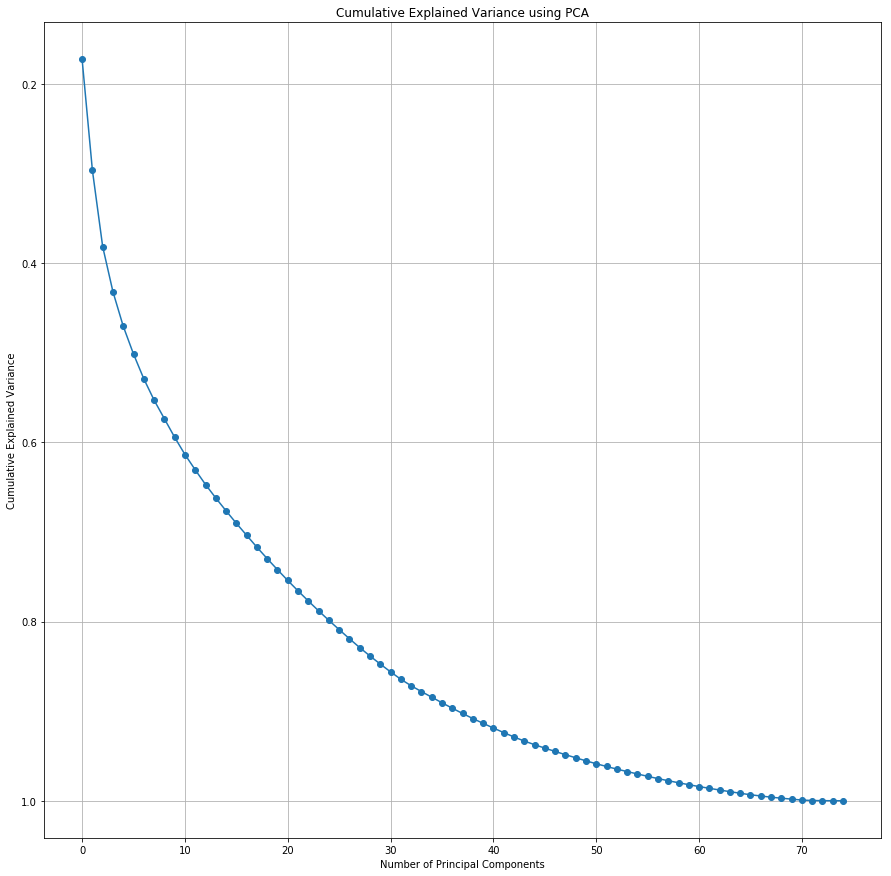

In [38]:
# Investigate the variance accounted for by each principal component.
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(15, 15))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance using PCA')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

For this analysis, we are aiming to keep about 90% of cumulative explained variance, so we will select `40` as our number of components.

In [39]:
# Re-apply PCA to the data while selecting for number of components to retain.
pca = PCA(n_components=40)
data1_pca_new = pca.fit_transform(data1_scaled)

print(np.cumsum(pca.explained_variance_ratio_))

[ 0.17254896  0.29627127  0.38146078  0.43192117  0.47035394  0.50144405
  0.52904263  0.55282862  0.57360678  0.59432019  0.61351896  0.6306309
  0.64700101  0.66209624  0.67639656  0.69032246  0.70369025  0.71699922
  0.72976883  0.74211324  0.75414033  0.76577412  0.77703467  0.78803914
  0.79865884  0.80900782  0.81919335  0.82906746  0.83846789  0.84748192
  0.85615508  0.86443934  0.87163269  0.87813607  0.88439852  0.89064466
  0.89670058  0.90258457  0.90820786  0.91355027]


### Discussion 2.2: Perform Dimensionality Reduction

We are keeping 40 principal components for our next step of the analysis, as we want to retain roughly 90% of our cumulative explained variance.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [40]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.

feature_names = data1.columns.tolist()

def print_pca_weights(pca, feature_names, component_index):
    # Get the weights for the component
    weights = pca.components_[component_index]
    
    # Create a dataframe so we can view the results
    df = pd.DataFrame({
        'Feature': feature_names,
        'Weight': weights
    })
    
    # Sort by weight descending
    df_sorted = df.sort_values(by='Weight', ascending=False)
    print(f"Principal Component {component_index + 1} feature weights:")
    print(df_sorted)
    print("\n")

# Print our first principle component
print_pca_weights(pca, feature_names, component_index=0) 

Principal Component 1 feature weights:
                           Feature    Weight
64                      PLZ8_ANTG3  0.195661
39              HH_EINKOMMEN_SCORE  0.194835
65                      PLZ8_ANTG4  0.189419
73                    CAMEO_WEALTH  0.186299
69                     ORTSGR_KLS9  0.165492
54                        EWDICHTE  0.163054
8                 FINANZ_HAUSBAUER  0.150519
4                    FINANZ_SPARER  0.144993
36                        ZABEOTYP  0.139092
51                     KBA05_ANTG4  0.137099
63                      PLZ8_ANTG2  0.130227
50                     KBA05_ANTG3  0.127681
68                          ARBEIT  0.123625
42             ANZ_HAUSHALTE_AKTIV  0.123103
70                        RELAT_AB  0.112685
31                   SEMIO_PFLICHT  0.112404
71    PRAEGENDE_JUGENDJAHRE_DECADE  0.106067
21                       SEMIO_REL  0.106056
32                     SEMIO_TRADV  0.100093
27                       SEMIO_RAT  0.095759
22              

In [41]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.

print_pca_weights(pca, feature_names, component_index=1)

Principal Component 2 feature weights:
                           Feature    Weight
0             ALTERSKATEGORIE_GROB  0.248620
25                       SEMIO_ERL  0.222204
5                 FINANZ_VORSORGER  0.216247
24                      SEMIO_LUST  0.170925
18                  RETOURTYP_BK_S  0.161252
40                  W_KEIT_KIND_HH  0.125511
28                      SEMIO_KRIT  0.117272
8                 FINANZ_HAUSBAUER  0.117050
33                     SHOPPER_TYP  0.104701
9                        FINANZTYP  0.104268
30                      SEMIO_KAEM  0.103759
64                      PLZ8_ANTG3  0.096041
65                      PLZ8_ANTG4  0.091791
54                        EWDICHTE  0.089091
69                     ORTSGR_KLS9  0.088766
1                        ANREDE_KZ  0.081954
73                    CAMEO_WEALTH  0.076249
51                     KBA05_ANTG4  0.069246
68                          ARBEIT  0.068925
70                        RELAT_AB  0.063185
63              

In [42]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.

print_pca_weights(pca, feature_names, component_index=2) 

Principal Component 3 feature weights:
                           Feature    Weight
23                      SEMIO_VERT  0.338596
19                       SEMIO_SOZ  0.260174
20                       SEMIO_FAM  0.254331
26                      SEMIO_KULT  0.235545
3                FINANZ_MINIMALIST  0.144891
9                        FINANZTYP  0.111326
18                  RETOURTYP_BK_S  0.110425
40                  W_KEIT_KIND_HH  0.096588
21                       SEMIO_REL  0.087790
5                 FINANZ_VORSORGER  0.085163
0             ALTERSKATEGORIE_GROB  0.067632
24                      SEMIO_LUST  0.060452
22                       SEMIO_MAT  0.056353
69                     ORTSGR_KLS9  0.055034
54                        EWDICHTE  0.054297
65                      PLZ8_ANTG4  0.054204
64                      PLZ8_ANTG3  0.053533
11                GREEN_AVANTGARDE  0.043145
72  PRAEGENDE_JUGENDJAHRE_MOVEMENT  0.043145
68                          ARBEIT  0.040179
70              

### Discussion 2.3: Interpret Principal Components

We do see highly positively and negatively correlated values in our analysis of principal components! It is also interesting that each one seems to follow a normal distribution. Our PC1 is positively influenced the most by `PLZ8_ANTG3`, and PC2 and PC3 are most positively influenced by `ALTERSKATEGORIE_GROB` and `SEMIO_VERT`, respectively.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [45]:
from sklearn.cluster import KMeans

score_list = []
for k in range(2,15):
    kmeans = KMeans(n_clusters = k)
    model = kmeans.fit(data1_pca_new)
    score_list.append(kmeans.score(data1_pca_new))

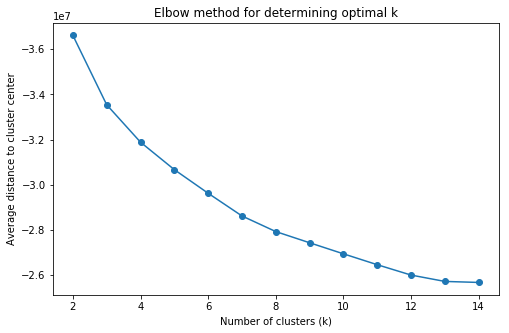

In [46]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.

plt.figure(figsize=(8,5))
plt.plot(range(2,15), score_list, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average distance to cluster center')
plt.title('Elbow method for determining optimal k')
plt.gca().invert_yaxis()
plt.show()

Based on our graph, it looks like `k = 13` is the best k-value for our dataset, as the graph 'smooths out' more after this point.

In [47]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.

k_final = 13
kmeans_final = KMeans(n_clusters=k_final)
cluster_model = kmeans_final.fit_predict(data1_pca_new)

### Discussion 3.1: Apply Clustering to General Population

Based on our graph, the elbow of the data appears to be at `k = 13`, so this is the number of clusters we have decided to select for our analysis.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [52]:
# Load in the customer demographics data.
customers = pd.read_csv("Udacity_CUSTOMERS_Subset.csv", sep=';')
# azdias = pd.read_csv("Udacity_AZDIAS_Subset.csv", sep=';')
# azdias_clean = clean_data(azdias, summary)
# assert azdias_clean.shape[1] == data1.shape[1], "clean_data function is not working properly, columns mismatch"

**We already completed all the preprocessing as `data2`, so we can use that and continue!**

In [53]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

customers_clean = clean_data(customers, summary)
customers_scaled = scaler.transform(customers_clean)
customers_pca = pca.transform(customers_scaled)
customer_clusters = kmeans_final.predict(customers_pca)

# Store cluster assignments
customers_clean['Cluster'] = customer_clusters
data1['Cluster'] = cluster_model

### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

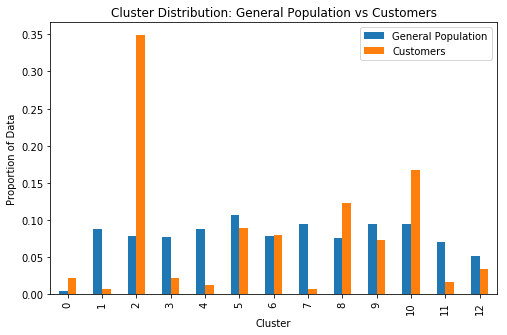

In [54]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.

pop_cluster_prop = (
    data1['Cluster']
    .value_counts(normalize=True)
    .sort_index()
)

cust_cluster_prop = (
    customers_clean['Cluster']
    .value_counts(normalize=True)
    .sort_index()
)

cluster_props = pd.DataFrame({
    'General Population': pop_cluster_prop,
    'Customers': cust_cluster_prop
})

cluster_props.plot(kind='bar', figsize=(8,5))
plt.ylabel('Proportion of Data')
plt.xlabel('Cluster')
plt.title('Cluster Distribution: General Population vs Customers')
plt.show()

Just by looking at this graph, we can see that cluster 2 is the most overrepresented, and cluster 7 is the most underrepresented. Let's analyze further to find out what kind of people these clusters represent.

In [83]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?
cluster_id = 2
o_cluster_data = scaler.inverse_transform(np.dot(customers_pca, pca.components_))
o_cluster_data = o_cluster_data[np.where(customer_clusters == cluster_id)]
o_cluster_df = pd.DataFrame(o_cluster_data, columns=feature_columns)

In [84]:
feature_columns = data1.drop(columns=['Cluster']).columns

# Reconstruct customer data
o_cluster_data = scaler.inverse_transform(
    np.dot(customers_pca, pca.components_)
)

# Select only rows belonging to the cluster
o_cluster_data = o_cluster_data[np.where(customer_clusters == cluster_id)]

# Convert to DataFrame
o_cluster_df = pd.DataFrame(
    o_cluster_data,
    columns=feature_columns
)

o_cluster_df.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
0,4.178618,0.903009,5.002187,5.207360,0.869822,4.774698,0.396493,2.494760,2.431665,2.621743,4.148268,0.995370,1.040111,3.403721,2.146462,10.216494,5.041987,1.004438,5.004385,6.000552,4.923686,2.777669,4.422967,7.625881,7.004782,4.554072,4.261933,1.545062,3.224912,1.679325,1.305569,1.642979,2.278589,2.772363,-0.000491,0.900878,2.563154,1.688048,0.000516,1.794277,6.407531,8.995706,-0.023738,0.010617,0.941720,5.354039,1992.111129,1.048905,2.343713,1.994897,0.017438,0.021649,3.864895,3.874481,2.701130,4.605785,3.850001,0.719760,4.067410,2.946248,1.254575,1244.166815,2.951342,3.025399,0.962946,-0.011959,4.732446,5.234217,1.288693,2.950895,0.153823,1956.318930,0.995370,1.537638,3.193545
1,3.064357,1.086807,3.912367,4.621767,0.972565,5.493591,0.803174,1.525210,2.986063,4.837173,10.914719,1.051252,3.101367,2.873227,1.934346,7.297061,3.824901,0.998872,2.879351,6.417813,4.877521,3.447364,2.254684,5.728219,5.463864,3.948151,4.583983,2.304611,3.982154,4.169183,2.839011,3.616950,2.858357,1.106319,0.000098,2.104881,2.006418,1.705366,-0.001119,2.391600,6.098202,9.173801,-1.143491,0.017945,1.047682,1.938776,1991.966191,1.151345,1.749373,1.848937,0.938690,0.008573,3.179113,7.026524,4.271480,6.450893,3.997193,1.884782,3.128649,3.171987,3.269033,1093.101912,2.210683,2.966328,2.142549,1.142225,5.410950,4.668303,3.500929,5.604242,4.783253,1957.978472,1.051252,2.104490,4.009914
2,3.312469,1.158763,2.055548,5.240574,0.679035,5.560718,1.261194,1.702164,2.825936,2.400381,9.948882,0.948950,1.825143,2.519320,1.836686,11.299787,5.336224,1.006130,5.068327,3.882011,4.143533,3.900367,1.454351,5.688226,5.085777,3.673035,4.487224,2.393592,2.122909,2.300527,2.095405,2.584687,2.566417,-0.100305,0.000180,1.005092,1.228151,1.796478,0.000816,1.659422,5.655801,8.865796,2.596980,-0.013883,1.015368,4.107969,1992.049680,0.992220,3.127067,0.846133,-0.005978,0.027980,4.070877,6.079769,2.538204,5.425317,3.972385,2.015283,4.477506,3.650720,3.078293,1221.537757,3.196859,2.242047,0.843299,0.204437,4.980460,5.300255,2.114735,2.987183,1.749795,1954.481316,0.948950,1.573720,2.832995
3,4.053377,0.907297,2.136519,5.434590,0.765179,4.667429,0.290352,1.995768,2.105357,4.918642,8.038043,1.023981,1.080785,3.300425,2.104146,9.883218,4.935665,0.997162,4.617470,5.924254,5.011205,3.011125,4.415110,7.551156,7.115667,4.492104,4.570844,1.841651,2.882021,2.251603,1.687495,1.870648,2.617758,2.692087,-0.000262,0.905566,2.584708,1.717958,0.000641,1.781953,6.005780,8.777943,0.570586,0.006154,0.932160,3.343793,1991.979153,0.905077,2.682237,1.844583,-0.106294,-0.011637,3.986386,6.081586,3.805284,4.641268,3.908430,0.828894,4.156460,2.432778,1.217694,444.816632,2.615245,2.874748,1.308748,0.443171,3.020619,3.244023,2.653187,4.369228,2.895905,1956.386099,1.023981,1.042789,5.111894
4,2.929549,1.045670,2.791922,4.949454,1.927414,4.323378,1.492383,3.047956,1.050618,2.197825,0.790856,1.008962,3.060437,7.686726,4.120099,10.614430,5.126645,0.994597,2.227223,5.878008,4.672608,3.854396,1.677868,5.974685,4.177727,3.697162,4.954282,2.354328,

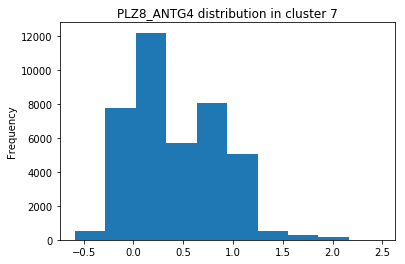

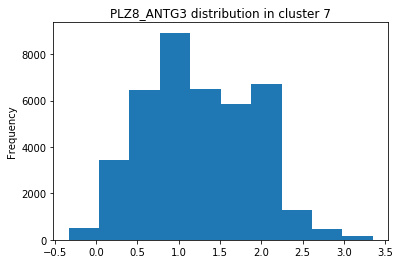

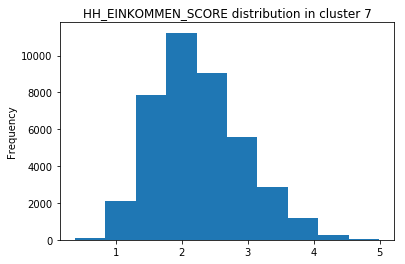

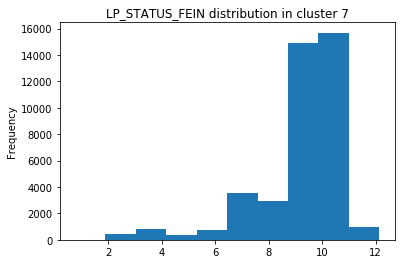

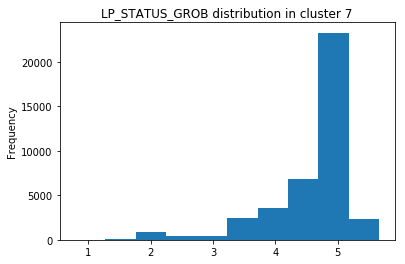

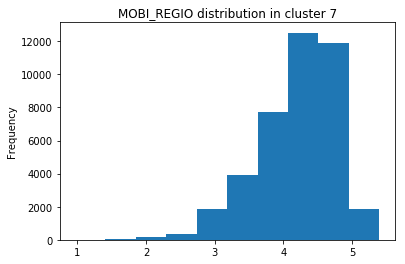

In [88]:
prominent_features = [
    'PLZ8_ANTG4', 'PLZ8_ANTG3', 'HH_EINKOMMEN_SCORE', #first 3 of PC1 
    'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'MOBI_REGIO' #last 3 of PC1
]

for feature in prominent_features:
    plt.figure(figsize=(6,4))
    if o_cluster_df[feature].dtype == 'O' or len(o_cluster_df[feature].unique()) < 10:
        o_cluster_df[feature].value_counts().sort_index().plot(kind='bar')
    else:
        o_cluster_df[feature].plot(kind='hist', bins=10)
    plt.title(f'{feature} distribution in cluster {cluster_id}')
    plt.show()

In [89]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?

cluster_id = 7

u_cluster_data = scaler.inverse_transform(
    np.dot(customers_pca, pca.components_)
)

u_cluster_data = u_cluster_data[np.where(customer_clusters == cluster_id)]

u_cluster_df = pd.DataFrame(
    u_cluster_data,
    columns=feature_columns
)

u_cluster_df.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,PRAEGENDE_JUGENDJAHRE_DECADE,PRAEGENDE_JUGENDJAHRE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE
0,1.948651,2.106993,3.773661,2.412920,2.713343,3.488299,2.281197,2.833270,2.698043,2.547486,7.045768,-0.021451,1.937685,0.808130,1.096608,4.390988,2.401738,0.999077,3.384274,4.884318,3.442876,4.484369,3.529992,2.319119,1.494820,4.808212,3.320936,5.927233,5.986397,6.660724,6.522264,5.963687,5.751021,3.168587,0.000247,1.043685,6.082202,0.846317,-0.001097,5.808778,2.906194,3.381690,6.444425,0.010539,7.898441,2.968107,1997.070820,1.219504,-0.164994,2.820641,1.968121,-0.016704,2.433736,2.361726,4.030608,4.654840,4.068642,1.718283,1.738897,3.629300,2.622080,774.399325,2.231593,2.690815,1.578592,0.753780,3.823101,3.625502,2.269225,5.110506,2.627276,1977.826567,-0.021451,4.193312,1.252484
1,1.528185,1.916860,0.778946,2.801524,1.303076,5.311605,1.082545,1.495455,4.913472,2.483534,4.999038,-0.009515,3.073867,1.085815,1.122673,3.243773,1.887323,1.011550,4.205357,4.868091,4.197338,5.452666,4.250121,2.268693,2.542987,3.740110,4.587827,6.474050,6.730799,6.992207,6.548811,6.768474,6.339670,2.027459,0.000122,1.987845,6.105838,0.924962,-0.001492,5.747379,6.603413,9.287246,3.543059,0.022921,1.068590,1.114045,1992.016328,1.018672,0.128874,2.947010,1.919263,-0.023281,2.196432,1.855362,6.178290,2.253512,3.952523,3.291427,1.705852,0.672703,6.449441,363.457809,1.884759,3.713358,2.187182,0.743498,3.286574,2.868992,3.864013,8.005512,3.989784,1957.525203,-0.009515,4.886574,1.390445
2,1.435212,2.152265,3.055454,1.424089,4.270396,1.529315,4.471631,2.820695,3.861123,5.779543,11.990982,0.047820,3.056089,1.035322,1.197789,2.113117,1.249189,0.985465,2.602107,2.336249,2.983133,4.550922,3.664451,1.238467,3.144635,4.309317,3.219226,6.174301,6.447696,7.588290,6.752141,6.058887,5.780621,1.887542,-0.000106,2.001653,4.823343,0.956456,-0.002586,4.458657,4.227140,2.931331,12.776871,0.040977,8.065806,5.408317,1994.955186,0.043261,0.858342,2.804527,0.865370,0.006719,3.220683,1.931566,5.127651,1.809535,4.810079,1.823557,2.880664,4.812570,2.791454,850.001478,1.671703,2.814873,2.108116,1.031766,4.565234,3.652021,4.089001,7.136617,2.637074,1991.137507,0.047820,2.123093,4.307407
3,1.376449,2.073119,3.097687,1.116169,4.110118,2.659211,3.616605,3.757776,4.105987,1.141033,7.961940,-0.074768,2.954563,6.304696,3.489820,1.371678,0.916088,2.018969,2.337111,4.977810,3.479553,4.542686,3.190061,2.136062,1.564960,4.346248,3.416798,5.922571,5.714375,7.414980,6.560445,6.074651,5.869477,2.949566,0.000237,2.055583,4.278766,2.621375,0.003697,5.338712,0.993288,8.746314,17.013447,-0.055993,1.052498,3.684110,1992.040527,0.932527,0.009132,1.993948,2.808134,-0.250668,2.277747,1.450370,4.856953,3.091952,3.077825,1.783157,1.909941,4.714812,2.304770,730.477985,1.365764,4.194171,2.547374,0.972532,3.836790,3.012842,2.580211,6.192981,2.388822,1987.939522,-0.074768,3.599613,3.170170
4,2.102739,2.177864,3.130202,0.837812,4.355319,1.981264,3.350006,4.362284,4.450148,0.877285,8.084705,0.027943,1.930854,5.075648,2.922568,1.153393,0.808691,0.985246,1.674544,1.086842,3.538792,4.605496,6.055723,1.984340,6.481679,4.978215,3.094892,6.608838,

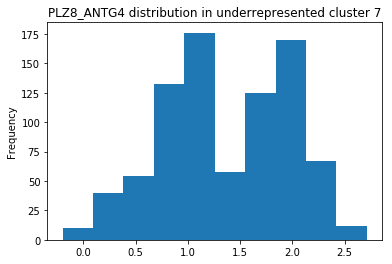

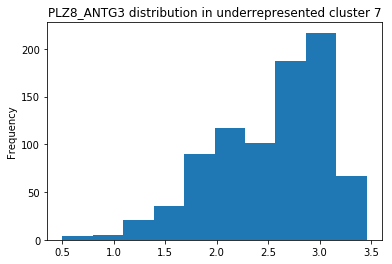

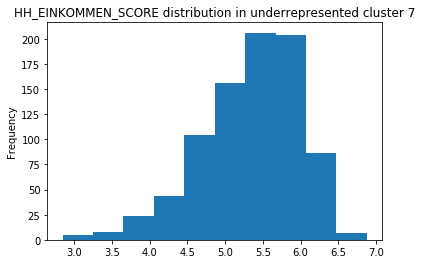

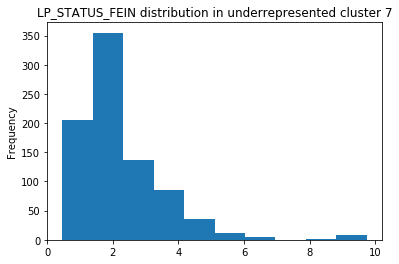

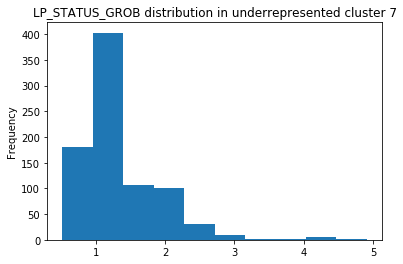

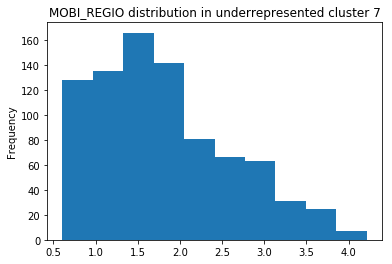

In [90]:
prominent_features = [
    'PLZ8_ANTG4', 'PLZ8_ANTG3', 'HH_EINKOMMEN_SCORE', #first 3 of PC1 
    'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'MOBI_REGIO' #last 3 of PC1
]

for feature in prominent_features:
    plt.figure(figsize=(6,4))
    if u_cluster_df[feature].dtype == 'O' or len(u_cluster_df[feature].unique()) < 10:
        u_cluster_df[feature].value_counts().sort_index().plot(kind='bar')
    else:
        u_cluster_df[feature].plot(kind='hist', bins=10)
    plt.title(f'{feature} distribution in underrepresented cluster {cluster_id}')
    plt.show()

### Discussion 3.3: Compare Customer Data to Demographics Data

Based on our analysis, we can see that clusters `3` and `7` are major outliers in the dataset. Cluster 3 makes up about 1/3 of our customers despite only representing ~10% of the population, and Cluster 7 contains around 10% of the population, but only represents about 1% of our customers! 

For our analysis, we selected the top 3 and bottom 3 columns of our first principal component in order to try to find the discrepancy.

We see that for cluster 3 (our overrepresented group):

- `PLZ8_ANTG4` is mostly at 0 to 1, representing low to no 10+ family homes within the area code, and `PLZ_ANTG3` is as well (1 to 2), suggesting minimal to average 6-10 family homes. This suggests that our overrepresented group lives in areas without high building density.

- `HH_EINKOMMEN_SCORE` is mostly at 2, which represents very high income earners. So, our overrepresented group mostly earns very high incomes.

- `LP_STATUS_FEIN` and `LP_STATUS_GROB` are both at the highest scale, showing that our overrepresented group are houseowners or top earners most of the time.

- `MOBI_REGIO` is mostly between 4 and 5, representing that our overrepresented group has low to very low movement patterns (i.e. they very rarely relocate).

And for cluster 7 (our underrepresented group):

- `PLZ8_ANTG4` mostly ranges from 1 to 2, representing higher numbers of 10+ family homes within the area code, and `PLZ_ANTG3` is mostly at 3, which would be a high share of 6-10 family homes. This suggests that our underrepresented group lives in areas with high building density.

- `HH_EINKOMMEN_SCORE` is mostly at 6, which represents extremely low income earners. So, our underrepresented group mostly earns very low incomes.

- `LP_STATUS_FEIN` is mostly at 2, and `LP_STATUS_GROB` is mostly at 1, showing that our underrepresented group are low-income earners and are typically orientation-seeking.

- `MOBI_REGIO` mostly ranges from 1 to 2 in our underrepresented group, showing that these types of customers have high to very high levels of movement / relocation.

This information can be used by the company so that they can better target new customers based on their demographic data and grow their overall reach. I hope you enjoyed this analysis!

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.